<a href="https://colab.research.google.com/github/Lara-mt/MAT-422/blob/main/MAT422_HW1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.3.1 QR Decomposition

QR decomposition factors a matrix A into two matrices, Q and R.

A = QR

The columns of Q are orthonormal, which means they are perpendicular to each other and each column has length 1. R is an upper triangular matrix.

I will use a small full-rank rectangular matrix and verify that (Q^T)*Q is approximately the identity matrix and QR reconstructs A.

In [1]:
import numpy as np

A = np.array([
    [1,3],
    [2,4],
])
Q,R = np.linalg.qr(A)

print("Matrix A:")
print(A)

print("\nMatrix Q:")
print(Q)

print("\nMatrix R:")
print(R)

Matrix A:
[[1 3]
 [2 4]]

Matrix Q:
[[-0.4472136  -0.89442719]
 [-0.89442719  0.4472136 ]]

Matrix R:
[[-2.23606798 -4.91934955]
 [ 0.         -0.89442719]]


In [3]:
print("\nQ transpose times Q:")
print(Q.T @ Q)

print("\nQ times R:")
print(Q @ R)

print("\nDoes Q^T Q equal the identity matrix?")
print(np.allclose(Q.T @ Q, np.eye(2)))

print("\nDoes Q times R equal A?")
print(np.allclose(Q @ R, A))


Q transpose times Q:
[[ 1.00000000e+00 -2.22918592e-16]
 [-2.22918592e-16  1.00000000e+00]]

Q times R:
[[1. 3.]
 [2. 4.]]

Does Q^T Q equal the identity matrix?
True

Does Q times R equal A?
True


Q has orthonormal columns because (Q^T)*Q is approximately the identity matrix. The product QR also reconstructs A, confirming that the QR decomposition was done right. Orthonormal columns are useful because they simplify calculations since the norm is only 1.

1.3.2 Least Squares Problems

Least Squares is used when a linear system has more equations than unknowns and an exact solution may not exist.

The goal is to find x so that A x is as close as possible to b.

r = b - A x

is called the residual. The least-squares solution minimizes the norm of this residual.

In [7]:
A = np.array([
    [1,1],
    [1,2],
    [1,3]
])
b = np.array([2,2,4])

x_hat, residuals, rank,singular_values = np.linalg.lstsq(A, b, rcond=None)

print("Matrix A:")
print(A)

print("\nVector b:")
print(b)

print("\nLeast-squares solution x:")
print(x_hat)

## Now Manually getting the residual
residual = b - A @ x_hat
residual_norm = np.linalg.norm(residual)

print("Residual vector:")
print(residual)

print("\nResidual norm:")
print(residual_norm)

# Check the normal-equation condition
normal_check = A.T @ residual

print("\nA transpose times residual:")
print(normal_check)

print("\nIs A^T r approximately zero?")
print(np.allclose(normal_check,0))

# Solve problem with least-squares using QR decomp
Q, R = np.linalg.qr(A)
x_qr = np.linalg.solve(R, Q.T @ b)

print("\nSolution using QR:")
print(x_qr)

print("\nDo the least-squares and QR solutions agree?")
print(np.allclose(x_hat, x_qr))


Matrix A:
[[1 1]
 [1 2]
 [1 3]]

Vector b:
[2 2 4]

Least-squares solution x:
[0.66666667 1.        ]
Residual vector:
[ 0.33333333 -0.66666667  0.33333333]

Residual norm:
0.816496580927726


This system has more equations than unknowns, so an exact solution does not necessarily exist.

The least-squares solution finds x_hat so that the residual b - A x_hat has the smallest possible norm.

The value of A^T times the residual is approximately zero, this shows that the residual is orthogonal to the columns of A.

The QR method gives the same approximate solution as np.linalg.lstsg, showing that QR decomposition can also be used to solve a least squares problem.

1.3.3 Linear Regression

Linear Regression uses least squares to find a line that best fits a set of data points.

The fitted line has the form:

y_hat = beta_0 + beta_1 * x

The coefficients beta_0 and beta_1 are chosen so that the residual errors between the observed y-values and predicted y-values are as small as possible.

Design matrix X:
[[1 1]
 [1 2]
 [1 3]
 [1 4]
 [1 5]]

Intercept (beta_0):
3.399999999999997

Slope (beta_1):
2.5514466478587775e-16

Predicted y-values:
[3.4 3.4 3.4 3.4 3.4]

Residuals:
[-1.4  0.6  1.6  0.6 -1.4]

Root Mean Squared Error (RMSE):
1.2


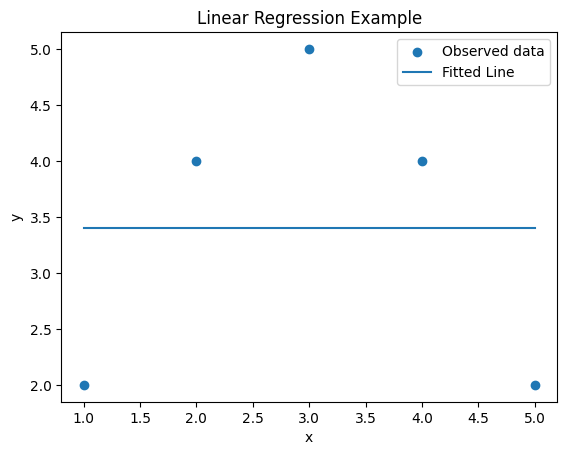

In [10]:
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,2])

X = np.column_stack([np.ones_like(x),x])

print("Design matrix X:")
print(X)

#Find the least-squares coefficients
beta,residuals,rank,singular_values = np.linalg.lstsq(X,y,rcond=None)

beta_0 = beta[0]
beta_1 = beta[1]

print("\nIntercept (beta_0):")
print(beta_0)

print("\nSlope (beta_1):")
print(beta_1)

#Predicted Values
y_hat = X @ beta

print("\nPredicted y-values:")
print(y_hat)

# Residual Values
residual = y - y_hat

print("\nResiduals:")
print(residual)

# Root mean squared error
rmse = np.sqrt(np.mean(residual**2))

print("\nRoot Mean Squared Error (RMSE):")
print(rmse)

# Plotting data and fitted line
import matplotlib.pyplot as plt

plt.scatter(x,y,label="Observed data")
plt.plot(x,y_hat,label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Example")
plt.legend()


The fitted regression line is nearly horizontal because the data does not show a consistent positive or negative linear trend. The slope is approximately 0, while the intercept is approximately 3.4. This means the model predicts a y-value near 3.4 regardless of x.

The Root mean squared error is 1.2, which measures the typical size of the prediction error.